# Red de artículos de la SEP como red compleja

**Objetivo.** Analizar la red de artículos de la Stanford Encyclopedia of Philosophy (SEP) como una red compleja, usando estudios de redes de Wikipedia como referencia metodológica.

## Motivación y pregunta del proyecto

La SEP es una base de conocimiento curada cuyos hipervínculos internos codifican cómo los temas filosóficos se refieren y dependen unos de otros. Una vista de red hace medibles esas dependencias: los puentes indican cuellos de botella conceptuales, los clústeres densos sugieren subdisciplinas y la topología global insinúa cómo se organiza la filosofía.

**Pregunta del proyecto:** ¿Cómo se compara la estructura de hipervínculos de la SEP con redes de conocimiento tipo Wikipedia y qué revelan las señales de centralidad y comunidad sobre los puentes entre subdisciplinas filosóficas?

## Preguntas del proyecto (guiadas por el artículo)

- ¿La red de artículos de la SEP muestra distribuciones de grado de entrada/salida/no dirigido amplias (de cola pesada) comparables a las redes de Wikipedia?
- ¿La reciprocidad de enlaces de la SEP se acerca más a la reciprocidad moderada de Wikipedia o a la mayor reciprocidad de la WWW?
- ¿Qué tan agrupada está la red de la SEP frente a una red aleatorizada con la misma distribución de grados?
- ¿La SEP es ligeramente disasortativa (como en el artículo de Wikipedia) o el contenido filosófico produce un patrón de mezcla distinto?
- ¿Las longitudes medias de camino de la SEP indican comportamiento de mundo pequeño frente a una línea base aleatoria?
- ¿Cuál es el tamaño de la SCC/WCC de la SEP y qué dice eso sobre la conectividad en una base de conocimiento curada?

## Revisión de artículos y selección principal

**Artículo principal (seleccionado):** *Complex networks reveal emergent interdisciplinary knowledge in Wikipedia* (Schwartz, 2021). Este trabajo propone minar Wikipedia para descubrir vínculos interdisciplinarios implícitos entre disciplinas y usa análisis de redes complejas para caracterizar comportamientos individuales y colectivos entre dominios.

**Otros artículos candidatos (revisados):**
- *A Deep Analysis of Node Roles and Connection Patterns in Wikilink Network* (Dong & Xia). Se centra en roles núcleo/borde, nodos de club diverso y mecanismos de transferencia de información en la red de enlaces de Wikipedia.
- *Evolution and Link Prediction of the Wikipedia Network* (Zhang, Shi, He). Estudia 18 instantáneas anuales del grafo de enlaces de Wikipedia, rastrea propiedades macroscópicas y evalúa métodos de predicción de enlaces.

**Ancla metodológica:** *Wikipedias as complex networks* (Zlatić et al., 2006) se usa aquí como plantilla metodológica para métricas a nivel de red (distribuciones de grado, reciprocidad, clustering, asortatividad, longitudes de camino).

## Alineación metodológica (modelo de red)

Modelamos las entradas de la SEP como nodos y los hipervínculos entre entradas como aristas dirigidas, en paralelo directo con el formalismo de redes de Wikipedia. Para análisis seleccionados (intermediación, clustering, longitudes de camino), también examinamos el mayor componente conectado no dirigido para estudiar proximidad conceptual en lugar de direccionalidad. Las líneas base del modelo de configuración permiten comparaciones para clustering y comportamiento de mundo pequeño.

## Lente interpretativa

Muchos análisis de redes de conocimiento tratan el contenido de los nodos como incidental. Este proyecto invierte esa lógica. La SEP está curada por expertos, así que cuando la centralidad de intermediación identifica un artículo puente, está haciendo una afirmación sobre la estructura profunda de la investigación filosófica: que ciertos problemas son tan fundamentales que hay que atravesarlos para pasar de un área de la filosofía a otra. La topología de la red se vuelve una herramienta para entender la estructura conceptual de la filosofia.

In [1]:
import json
import os
import pickle
import time
from urllib.parse import urljoin, urlparse

import networkx as nx
import requests
from bs4 import BeautifulSoup

In [2]:
SEP_BASE = "https://plato.stanford.edu"
SEP_HOST = "plato.stanford.edu"

session = requests.Session()
session.headers.update({
    # Configura un User-Agent descriptivo con contacto; revisa /robots.txt antes de rastrear.
    "User-Agent": "sep-link-grapher-research/1.0 (contact: jit.latter557@aleeas.com)"
})

## Adquisición de datos y construcción del grafo

Rastreamos la página de contenidos de la SEP para obtener la lista de slugs, luego visitamos cada entrada y extraemos los hipervínculos internos `/entries/`. Los resultados se almacenan en `sep_links.json` y el grafo se guarda en `sep_graph.pkl` para poder reanudar el rastreo y repetirlo con bajo costo.

In [3]:
def get_all_entries():
    """Obtiene todas las URLs de entradas de la SEP desde la tabla de contenidos. Devuelve {slug: titulo}."""
    r = session.get(f"{SEP_BASE}/contents.html", timeout=10)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "html.parser")
    entries = {}
    for a in soup.select("div#content a[href]"):
        href = a["href"]
        if href.startswith("entries/"):
            slug = href.rstrip("/").split("/")[-1]
            entries[slug] = a.text.strip()
    return entries

In [4]:
def get_entry_links(slug):
    """Obtiene los slugs internos de la SEP enlazados desde una entrada. Devuelve un conjunto de slugs."""
    url = f"{SEP_BASE}/entries/{slug}/"
    links = set()
    try:
        r = session.get(url, timeout=10)
        r.raise_for_status()
    except requests.RequestException as e:
        print(f"  ! {slug}: {e}")
        return links

    soup = BeautifulSoup(r.text, "html.parser")
    for a in soup.select("a[href]"):
        # urljoin resuelve ../ y fragmentos contra la URL de la página actual.
        p = urlparse(urljoin(url, a["href"]))
        # Solo enlaces internos de entradas: mismo host, ruta bajo /entries/.
        if p.netloc and p.netloc != SEP_HOST:
            continue
        if not p.path.startswith("/entries/"):
            continue
        target = p.path.split("/entries/", 1)[1].strip("/").split("/")[0]
        if target and target != slug:
            links.add(target)
    return links

In [5]:
def build_sep_graph(entries, graph_cache="sep_graph.pkl", links_cache="sep_links.json"):
    if os.path.exists(graph_cache):
        with open(graph_cache, "rb") as f:
            return pickle.load(f)

    # Caché por página para que un fallo a mitad del rastreo no pierda progreso; las reejecuciones se reanudan.
    if os.path.exists(links_cache):
        with open(links_cache) as f:
            crawled = {k: set(v) for k, v in json.load(f).items()}
    else:
        crawled = {}

    todo = [s for s in entries if s not in crawled]
    for i, slug in enumerate(todo):
        crawled[slug] = get_entry_links(slug)
        time.sleep(0.8)  # ser respetuosos con el servidor de la SEP
        if i % 50 == 0:
            print(f"  {i}/{len(todo)} — {entries[slug]}")
            with open(links_cache, "w") as f:
                json.dump({k: sorted(v) for k, v in crawled.items()}, f)

    with open(links_cache, "w") as f:
        json.dump({k: sorted(v) for k, v in crawled.items()}, f)

    G = nx.DiGraph()
    for slug, title in entries.items():
        G.add_node(slug, title=title)
    for slug, targets in crawled.items():
        for target in targets:
            if target in entries:
                G.add_edge(slug, target)

    with open(graph_cache, "wb") as f:
        pickle.dump(G, f)
    return G

In [6]:
if __name__ == "__main__":
    entries = get_all_entries()
    G = build_sep_graph(entries)
    print(f"Nodos: {G.number_of_nodes()}, Aristas: {G.number_of_edges()}")

Nodos: 1861, Aristas: 21977


## Análisis de centralidad

Seguimos la práctica estándar en la literatura sobre Wikipedia calculando intermediación y cercanía sobre el mayor componente conectado no dirigido (proximidad conceptual), mientras mantenemos PageRank en el grafo dirigido (prestigio/atención).

In [7]:
import pandas as pd
import numpy as np

# Trabajar con grafo no dirigido para intermediación
# (práctica estándar: interesa la proximidad conceptual, no la dirección del enlace)
G_u = G.to_undirected()

# Conservar solo el componente conectado más grande
lcc_nodes = max(nx.connected_components(G_u), key=len)
G_lcc = G_u.subgraph(lcc_nodes).copy()
print(f"LCC: {G_lcc.number_of_nodes()} nodos, {G_lcc.number_of_edges()} aristas")

# Intermediación exacta — viable a esta escala
print("Calculando intermediación (toma 2-5 min)...")
bc = nx.betweenness_centrality(G_lcc, normalized=True)
cc = nx.closeness_centrality(G_lcc)
dc = nx.degree_centrality(G_lcc)
pr = nx.pagerank(G, alpha=0.85)  # usar el grafo dirigido para PageRank

# Construir DataFrame de resultados con títulos legibles
df = pd.DataFrame({
    'slug':        list(bc.keys()),
    'title':       [entries.get(n, n) for n in bc.keys()],
    'betweenness': list(bc.values()),
    'closeness':   [cc[n] for n in bc],
    'degree':      [dc[n] for n in bc],
    'pagerank':    [pr.get(n, 0) for n in bc],
})

# La razón de puente: intermediación alta relativa al grado
df['bridge_ratio'] = df['betweenness'] / (df['degree'] + 1e-9)

display_columns = {
    'slug': 'identificador',
    'title': 'titulo',
    'betweenness': 'intermediacion',
    'closeness': 'cercania',
    'degree': 'grado',
    'pagerank': 'pagerank',
    'bridge_ratio': 'razon_puente',
}
df_display = df.rename(columns=display_columns)

# Tres listas ordenadas; cada una cuenta una historia distinta
print("\nTop 15 por intermediación (centralidad estructural):")
print(df_display.nlargest(15, 'intermediacion')[['titulo','intermediacion','grado']].to_string())

print("\nTop 15 por razón de puente (puentes ocultos):")
print(df_display.nlargest(15, 'razon_puente')[['titulo','intermediacion','grado','razon_puente']].to_string())

print("\nTop 15 por PageRank (centralidad ponderada por prestigio):")
print(df_display.nlargest(15, 'pagerank')[['titulo','pagerank','grado']].to_string())

LCC: 1861 nodos, 18970 aristas
Calculando intermediación (toma 2-5 min)...



Top 15 por intermediación (centralidad estructural):
                   titulo  intermediacion     grado
148             Aristotle        0.038667  0.071505
1249  medieval philosophy        0.029779  0.085484
124       Aquinas, Thomas        0.029047  0.061828
1032       Kant, Immanuel        0.028489  0.062903
1458                Plato        0.019435  0.049462
914           Hume, David        0.016066  0.046774
531       Descartes, René        0.015110  0.050538
449      consequentialism        0.014658  0.045161
1786              trinity        0.012730  0.041935
801             free will        0.012605  0.038172
1659    scientific method        0.012591  0.036022
1656    science: unity of        0.012579  0.034409
194            properties        0.012544  0.046237
685        ethics: virtue        0.011811  0.032258
110     animal: cognition        0.011735  0.027419

Top 15 por razón de puente (puentes ocultos):
                          titulo  intermediacion     grado  razon_p

### Comparación de señales de centralidad

Comparamos la intermediación (puentes estructurales) con PageRank (prestigio) para identificar puentes subvalorados y hubs de prestigio.

In [8]:
# Encontrar las discrepancias
top_bc  = set(df.nlargest(30, 'betweenness')['slug'])
top_pr  = set(df.nlargest(30, 'pagerank')['slug'])
top_br  = set(df.nlargest(30, 'bridge_ratio')['slug'])

# Intermediación alta pero NO PageRank alto = puentes subvalorados
underappreciated = top_bc - top_pr
print("Estructuralmente críticos pero no famosos:")
print(df_display[df_display['identificador'].isin(underappreciated)][['titulo','intermediacion','pagerank']])

# PageRank alto pero NO intermediación alta = hubs de prestigio
prestige_hubs = top_pr - top_bc
print("\nFamosos pero no estructuralmente críticos:")
print(df_display[df_display['identificador'].isin(prestige_hubs)][['titulo','intermediacion','pagerank']])

Estructuralmente críticos pero no famosos:
                              titulo  intermediacion  pagerank
110                animal: cognition        0.011735  0.000513
144       argument and argumentation        0.010322  0.000224
630                          emotion        0.008276  0.001418
685                   ethics: virtue        0.011811  0.002348
736              feminist philosophy        0.009090  0.000513
884   Hegel, Georg Wilhelm Friedrich        0.010032  0.002044
932                         idealism        0.011260  0.001119
945                      imagination        0.008904  0.000559
969                         infinity        0.009698  0.000412
1114                    Lewis, David        0.009523  0.001072
1249             medieval philosophy        0.029779  0.001750
1271                       mereology        0.008824  0.001838
1280                     metaphysics        0.010308  0.001335
1656               science: unity of        0.012579  0.000646
1659        

## Modelado/simulación y métricas a nivel de red

Calculamos las mismas estadísticas centrales destacadas en el estudio de Wikipedia: distribuciones de grado, reciprocidad, clustering, asortatividad y longitudes características de camino. Las líneas base del modelo de configuración aleatorizado actúan como simulaciones de un modelo nulo que preserva el grado para comparar clustering y longitudes de camino.

In [9]:
import collections

N = G.number_of_nodes()
L = G.number_of_edges()
density = nx.density(G)

recip = nx.reciprocity(G)
recip = 0.0 if recip is None else recip
a = L / (N * (N - 1))
rho = (recip - a) / (1 - a) if a < 1 else 0.0

sccs = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
wccs = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
largest_scc = G.subgraph(sccs[0]).copy()
largest_wcc = G.subgraph(wccs[0]).copy()

avg_path_undir = nx.average_shortest_path_length(G_lcc)
avg_path_dir = nx.average_shortest_path_length(largest_scc)

assort_undir = nx.degree_assortativity_coefficient(G_u)
assort_out_in = nx.degree_assortativity_coefficient(G, x='out', y='in')

clust_undir = nx.average_clustering(G_lcc)

deg_seq = [d for _, d in G_lcc.degree()]
G_rand = nx.configuration_model(deg_seq, seed=42)
G_rand = nx.Graph(G_rand)
G_rand.remove_edges_from(nx.selfloop_edges(G_rand))

rand_lcc_nodes = max(nx.connected_components(G_rand), key=len)
G_rand_lcc = G_rand.subgraph(rand_lcc_nodes).copy()
clust_rand = nx.average_clustering(G_rand_lcc)
rand_path = nx.average_shortest_path_length(G_rand_lcc)

summary = pd.DataFrame({
    "metrica": [
        "Nodos (N)",
        "Aristas (L)",
        "Densidad",
        "Reciprocidad r",
        "Reciprocidad rho (no sesgada)",
        "Tamaño de la WCC más grande",
        "Tamaño de la SCC más grande",
        "Longitud media de camino (LCC no dirigido)",
        "Longitud media de camino (SCC dirigido)",
        "Clustering (LCC no dirigido)",
        "Clustering (LCC modelo de configuración)",
        "Asortatividad (no dirigido)",
        "Asortatividad (salida-entrada)",
    ],
    "valor": [
        N,
        L,
        density,
        recip,
        rho,
        largest_wcc.number_of_nodes(),
        largest_scc.number_of_nodes(),
        avg_path_undir,
        avg_path_dir,
        clust_undir,
        clust_rand,
        assort_undir,
        assort_out_in,
    ],
})
summary

,metrica,valor
0,Nodos (N),1861.000000
1,Aristas (L),21977.000000
2,Densidad,0.006349
3,Reciprocidad r,0.273650
4,Reciprocidad rho (no sesgada),0.269009
5,Tamaño de la WCC más grande,1861.000000
6,Tamaño de la SCC más grande,1773.000000
7,Longitud media de camino (LCC no dirigido),3.072079
8,Longitud media de camino (SCC dirigido),3.901990
9,Clustering (LCC no dirigido),0.248803


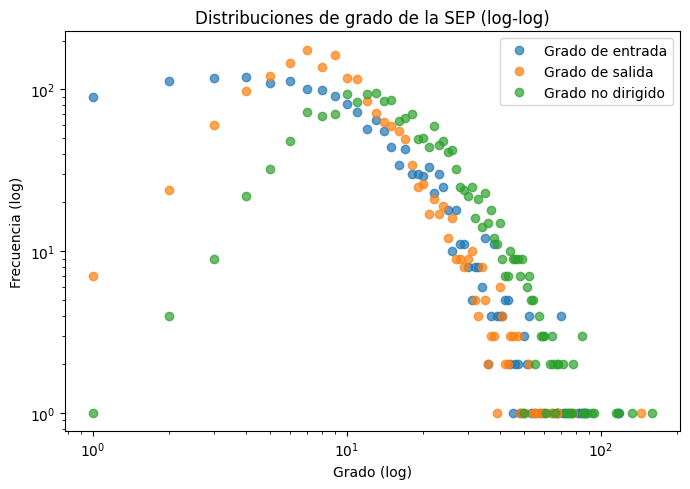

In [10]:
from collections import Counter
import matplotlib.pyplot as plt

def degree_hist(deg_dict):
    counts = Counter(deg_dict.values())
    xs = np.array(sorted(counts.keys()))
    ys = np.array([counts[x] for x in xs])
    return xs, ys

in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())
undir_deg = dict(G_u.degree())

x_in, y_in = degree_hist(in_deg)
x_out, y_out = degree_hist(out_deg)
x_und, y_und = degree_hist(undir_deg)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(x_in, y_in, 'o', alpha=0.7, label='Grado de entrada')
ax.loglog(x_out, y_out, 'o', alpha=0.7, label='Grado de salida')
ax.loglog(x_und, y_und, 'o', alpha=0.7, label='Grado no dirigido')
ax.set_xlabel('Grado (log)')
ax.set_ylabel('Frecuencia (log)')
ax.set_title('Distribuciones de grado de la SEP (log-log)')
ax.legend()
plt.tight_layout()

## Visualizaciones

Los gráficos siguientes resaltan nodos puente, señales por subdisciplina y la columna vertebral interactiva de la SEP.

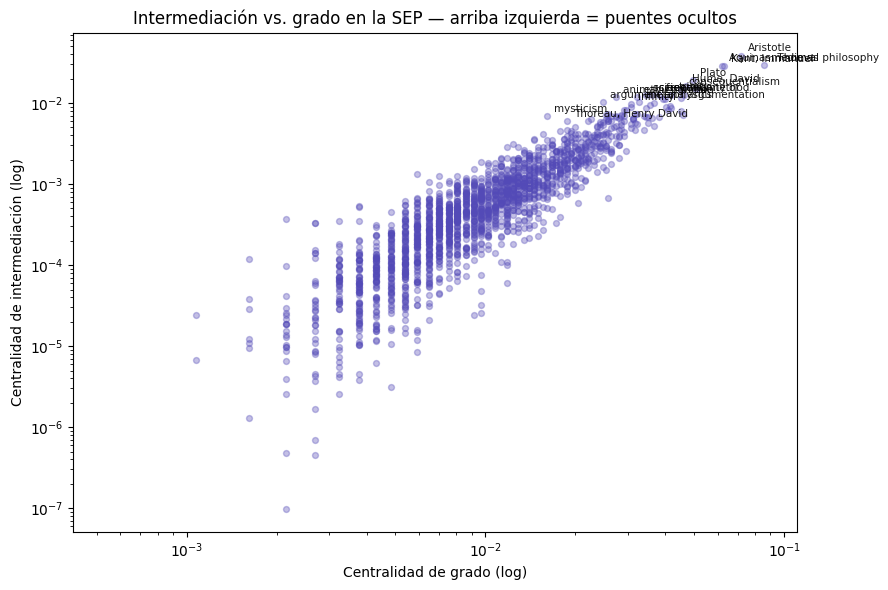

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['degree'], df['betweenness'],
           alpha=0.35, s=18, color='#534AB7')

# Anotar las entradas con mayor razón de puente (no solo mayor intermediación)
to_label = df.nlargest(18, 'bridge_ratio')
for _, row in to_label.iterrows():
    ax.annotate(row['title'][:28],
                (row['degree'], row['betweenness']),
                fontsize=7.5, alpha=0.9,
                xytext=(5, 3), textcoords='offset points')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Centralidad de grado (log)')
ax.set_ylabel('Centralidad de intermediación (log)')
ax.set_title('Intermediación vs. grado en la SEP — arriba izquierda = puentes ocultos')
plt.tight_layout()

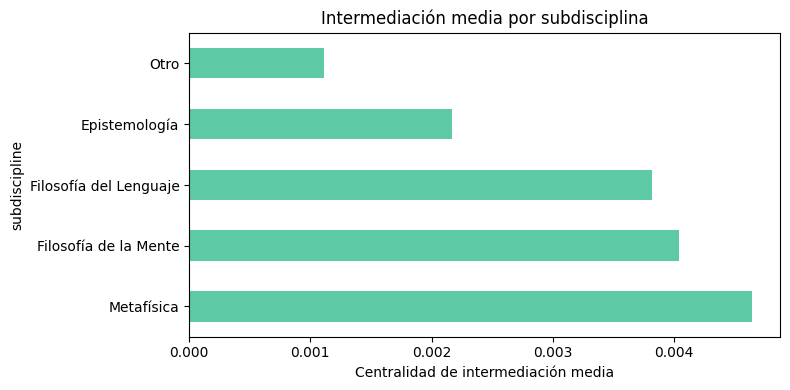

In [12]:
import seaborn as sns

# Asignar subdisciplinas manualmente desde categorías de la SEP
# (o usar palabras clave del título como aproximación)
subdiscipline_map = {
    'causation': 'Metafísica',
    'truth': 'Filosofía del Lenguaje',
    'consciousness': 'Filosofía de la Mente',
    'knowledge-analysis': 'Epistemología',
    'modality-epistemology': 'Epistemología',
    'possible-worlds': 'Metafísica',
    # ... ampliar para las entradas principales
}
df['subdiscipline'] = df['slug'].map(subdiscipline_map).fillna('Otro')

avg_bc = (df.groupby('subdiscipline')['betweenness']
            .mean()
            .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
avg_bc.plot(kind='barh', ax=ax, color='#5DCAA5')
ax.set_xlabel('Centralidad de intermediación media')
ax.set_title('Intermediación media por subdisciplina')
plt.tight_layout()

In [13]:
from pyvis.network import Network

# Colorear nodos por subdisciplina
color_map = {
    'Metafísica':             '#7F77DD',
    'Epistemología':          '#1D9E75',
    'Filosofía de la Mente':  '#D85A30',
    'Filosofía del Lenguaje': '#378ADD',
    'Ética':                  '#EF9F27',
    'Lógica':                 '#888780',
    'Otro':                   '#B4B2A9',
}

# Mostrar los 300 nodos principales por intermediación
top = df.nlargest(300, 'betweenness')['slug'].tolist()
G_vis = G_lcc.subgraph(top)

net = Network(height='680px', notebook=True)
for node in G_vis.nodes():
    row = df[df['slug'] == node].iloc[0]
    sub = subdiscipline_map.get(node, 'Otro')
    net.add_node(node,
                 label=row['title'][:30],
                 size=row['betweenness'] * 4000 + 6,
                 color=color_map.get(sub, '#B4B2A9'),
                 title=f"{row['title']}<br>Intermediación: {row['betweenness']:.4f}<br>Razón de puente: {row['bridge_ratio']:.2f}")
for u, v in G_vis.edges():
    net.add_edge(u, v, width=0.4, color='#D3D1C7')

net.show('sep_bridges.html')

sep_bridges.html


## Discusión y conclusiones

## Declaración de uso de IA
